<div style="background:linear-gradient(135deg,#4c0519 0%,#be123c 55%,#fb7185 100%);border-radius:18px;padding:34px 30px;color:#fff;font-family:Inter,Segoe UI,sans-serif">
  <div style="font-size:12px;letter-spacing:3px;color:#fecdd3;font-weight:700;text-transform:uppercase">Chapter 63 · Sampling &amp; Data Collection</div>
  <div style="font-size:34px;font-weight:900;line-height:1.1;margin:10px 0 6px">Non-Probability Sampling Methods ⚠️</div>
  <div style="font-size:15px;color:#fff1f2;max-width:740px;line-height:1.6">Convenience, voluntary response, quota, and snowball sampling are cheap and common, but selection probabilities are unknown. We simulate the selection bias each one bakes in, and watch it survive any amount of extra data.</div>
  <div style="margin-top:16px;font-size:13px;color:#fecdd3">Statistics, Data Science and AI: A Visual Handbook · John Fisher · 2026</div>
</div>

## ⚙️ Setup &amp; population

In [1]:
import numpy as np, matplotlib.pyplot as plt
ROSE="#e11d48"; DEEP="#be123c"; LIGHT="#fb7185"; INK="#1a2138"; GRID="#e6e9f2"; TEAL="#0d9488"
plt.rcParams.update({"figure.facecolor":"white","axes.facecolor":"white","figure.dpi":110,"font.size":11,
   "axes.edgecolor":GRID,"axes.grid":True,"grid.color":GRID,"axes.axisbelow":True,"axes.spines.top":False,
   "axes.spines.right":False,"axes.titlesize":12,"axes.titleweight":"bold","legend.frameon":False})
rng = np.random.default_rng(63)
N = 200_000
# survey question: hours per week on a new app. Younger users use it more AND are easier to reach online.
age = rng.integers(18, 78, N)
hours = np.clip(rng.normal(20 - 0.22*(age-18), 6), 0, None)   # younger -> more hours
TRUE = hours.mean()
print(f"population: N={N:,}, TRUE mean usage = {TRUE:.2f} hours/week")

population: N=200,000, TRUE mean usage = 13.60 hours/week


<div style="background:#fff1f2;border-left:5px solid #e11d48;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#be123c;letter-spacing:1px">DEMO 1 · CONVENIENCE SAMPLING</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Whoever is easiest to reach</div>
<div style="color:#4a5578;margin-top:6px">Convenience sampling grabs the most accessible people, here, online users, who skew young. Because age is tied to the answer, the easy-to-reach group is not representative, and the estimate is biased no matter how many we collect.</div>
</div>

In [2]:
# reachability is higher for younger people (online recruiting)
reach_prob = 1/(1+np.exp(0.12*(age-35)))         # young people far more reachable
reachable = rng.random(N) < reach_prob
pool = np.where(reachable)[0]
print(f"reachable pool: {len(pool):,} people, mean age {age[pool].mean():.0f} vs population {age.mean():.0f}")
for n in [100, 1000, 20000]:
    s = hours[rng.choice(pool, n, replace=False)]
    print(f"convenience sample n={n:>6}: estimate = {s.mean():.2f} h  (bias {s.mean()-TRUE:+.2f})")
print(f"\ntrue mean = {TRUE:.2f}: the bias does not shrink as n grows")

reachable pool: 61,221 people, mean age 31 vs population 47
convenience sample n=   100: estimate = 16.65 h  (bias +3.06)
convenience sample n=  1000: estimate = 17.39 h  (bias +3.80)
convenience sample n= 20000: estimate = 17.10 h  (bias +3.50)

true mean = 13.60: the bias does not shrink as n grows


Every convenience sample over-estimates usage by a few hours, and the bias is the same at n=100 and n=20,000. The error is systematic: the easy-to-reach pool genuinely differs from the population, so collecting more of it cannot help.

<div style="background:#fff1f2;border-left:5px solid #e11d48;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#be123c;letter-spacing:1px">DEMO 2 · VOLUNTARY RESPONSE</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Only the strongly-opinionated answer</div>
<div style="color:#4a5578;margin-top:6px">In a voluntary poll (a website pop-up), people with extreme views are far likelier to respond. We model satisfaction on a 0-10 scale where the very happy and the very angry self-select, distorting both the mean and the shape.</div>
</div>

In [3]:
satisfaction = np.clip(rng.normal(6.5, 1.8, N), 0, 10)
print(f"TRUE mean satisfaction = {satisfaction.mean():.2f}")
# response probability is U-shaped: extremes respond, moderates stay silent
resp_prob = 0.02 + 0.5*((satisfaction-5)/5)**2
responders = rng.random(N) < resp_prob
volunteer = satisfaction[responders]
print(f"voluntary-response estimate = {volunteer.mean():.2f}  (n={responders.sum():,})")
print(f"share rating 0-2 or 9-10: population {np.mean((satisfaction<=2)|(satisfaction>=9))*100:.0f}%  vs  volunteers {np.mean((volunteer<=2)|(volunteer>=9))*100:.0f}%")

TRUE mean satisfaction = 6.48
voluntary-response estimate = 7.82  (n=25,304)
share rating 0-2 or 9-10: population 9%  vs  volunteers 31%


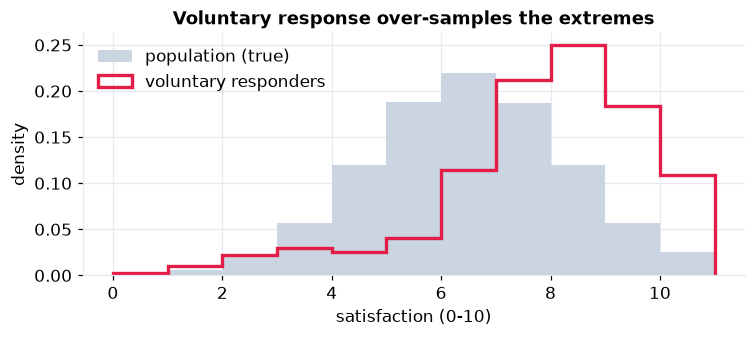

In [4]:
fig,ax=plt.subplots(figsize=(7,3.2))
ax.hist(satisfaction, bins=np.arange(0,11.5,1), density=True, color="#cbd5e1", label="population (true)")
ax.hist(volunteer, bins=np.arange(0,11.5,1), density=True, histtype="step", lw=2.2, color=ROSE, label="voluntary responders")
ax.set_xlabel("satisfaction (0-10)"); ax.set_ylabel("density"); ax.set_title("Voluntary response over-samples the extremes"); ax.legend()
plt.tight_layout(); plt.show()

The population is a single moderate hump, but the volunteers are piled at the two ends, the delighted and the furious. Voluntary-response samples exaggerate polarization and can shift the mean in either direction. This is why online star-ratings look so divided.

<div style="background:#fff1f2;border-left:5px solid #e11d48;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#be123c;letter-spacing:1px">DEMO 3 · QUOTA SAMPLING</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Right margins, wrong middle</div>
<div style="color:#4a5578;margin-top:6px">Quota sampling fixes the proportions of visible traits (say, age bands) to match the population, then fills each quota with convenient people. The margins look right, but bias hides INSIDE each quota wherever a lurking variable lives.</div>
</div>

In [5]:
# within each age band, interviewers still pick the most willing (higher-usage) people
bands = np.digitize(age, [30,45,60])
def quota_sample(n=4000):
    pop_share = np.array([np.mean(bands==b) for b in range(4)])
    picks=[]
    for b in range(4):
        idx = np.where(bands==b)[0]
        # convenience WITHIN the band: prefer high-usage (more willing) respondents
        w = hours[idx] + 1
        chosen = rng.choice(idx, round(n*pop_share[b]), replace=False, p=w/w.sum())
        picks.append(hours[chosen])
    return np.concatenate(picks)
q = quota_sample()
print(f"quota sample matches age proportions, estimate = {q.mean():.2f}  (bias {q.mean()-TRUE:+.2f})")
print(f"vs pure convenience bias ~ +3 to +4: quota helps, but residual bias remains")

quota sample matches age proportions, estimate = 16.14  (bias +2.54)
vs pure convenience bias ~ +3 to +4: quota helps, but residual bias remains


Quota sampling shrinks the bias by forcing the visible proportions to match, but it does not eliminate it: choosing the most willing people inside each quota leaves a residual skew. Quotas control only the variables you quota on, never the lurking ones.

<div style="background:#fff1f2;border-left:5px solid #e11d48;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#be123c;letter-spacing:1px">DEMO 4 · SNOWBALL SAMPLING</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Referrals over-sample the well-connected</div>
<div style="color:#4a5578;margin-top:6px">For hidden populations (rare communities), snowball sampling asks each respondent to refer others. Selection then favors highly-connected people, who often differ from isolated members, so the estimate tilts toward the social core.</div>
</div>

In [6]:
connections = rng.integers(0, 50, N)               # social connectedness
# the well-connected use the app more (network effects)
hours_sn = np.clip(rng.normal(14 + 0.18*connections, 5), 0, None)
print(f"TRUE mean usage = {hours_sn.mean():.2f}")
# snowball: probability of being referred grows with number of connections
p_ref = connections / connections.sum()
snow = hours_sn[rng.choice(N, 3000, replace=False, p=p_ref)]
print(f"snowball estimate = {snow.mean():.2f}  (bias {snow.mean()-hours_sn.mean():+.2f})")
print(f"sampled mean connections {connections[rng.choice(N,3000,replace=False,p=p_ref)].mean():.0f} vs population {connections.mean():.0f}")

TRUE mean usage = 18.40
snowball estimate = 19.73  (bias +1.33)
sampled mean connections 33 vs population 24


Snowball sampling reaches otherwise-invisible groups, its real strength, but it over-represents the socially central, biasing any trait correlated with connectedness. It is a pragmatic last resort, not a representative method.

<div style="background:#fff1f2;border-left:5px solid #e11d48;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#be123c;letter-spacing:1px">DEMO 5 · THE VERDICT: BIASED vs CENTERED</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Non-probability misses, probability hits</div>
<div style="color:#4a5578;margin-top:6px">Side by side, a convenience method and a simple random sample on the same question. The random sample centers on the truth; the convenience sample is shifted off it, and more data only sharpens the wrong answer.</div>
</div>

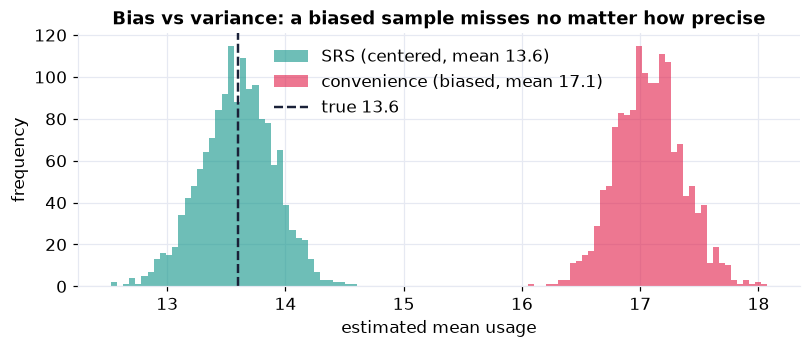

SRS bias -0.00 (just noise) | convenience bias +3.48 (systematic)


In [7]:
conv = np.array([hours[rng.choice(pool, 500, replace=False)].mean() for _ in range(1500)])
srs  = np.array([hours[rng.choice(N,    500, replace=False)].mean() for _ in range(1500)])
fig,ax=plt.subplots(figsize=(7.5,3.3))
ax.hist(srs, bins=40, color=TEAL, alpha=0.6, label=f"SRS (centered, mean {srs.mean():.1f})")
ax.hist(conv, bins=40, color=ROSE, alpha=0.6, label=f"convenience (biased, mean {conv.mean():.1f})")
ax.axvline(TRUE, color=INK, ls="--", lw=1.6, label=f"true {TRUE:.1f}")
ax.set_xlabel("estimated mean usage"); ax.set_ylabel("frequency"); ax.set_title("Bias vs variance: a biased sample misses no matter how precise"); ax.legend()
plt.tight_layout(); plt.show()
print(f"SRS bias {srs.mean()-TRUE:+.2f} (just noise) | convenience bias {conv.mean()-TRUE:+.2f} (systematic)")

The random sample brackets the truth; the convenience sample sits firmly to one side. No confidence interval built from a non-probability sample is trustworthy, because the bias is not captured by the formula. When you cannot run a probability sample, you can sometimes <em>weight</em> the data to correct known imbalances, the subject of later inference chapters.

---
<div style="background:#ffffff;border:1px solid #e6e9f2;border-radius:16px;padding:22px 26px;font-family:Inter,sans-serif">
<div style="font-size:19px;font-weight:800;color:#1a2138">⚠️ Non-probability sampling</div>
<div style="color:#4a5578;line-height:1.8;margin-top:8px">Convenience, voluntary, quota, and snowball sampling are fast and cheap but carry unknown selection probabilities, so they bake in selection bias that no extra data removes. Convenience over-samples the reachable, voluntary response the opinionated, quota leaves residual bias inside quotas, and snowball favors the well-connected. Use them when probability sampling is impossible, and treat their margins of error with deep suspicion.</div>
</div>

<div style="text-align:center;color:#8b94b3;font-size:12px;margin-top:16px">Statistics, Data Science and AI: A Visual Handbook · © 2026 John Fisher</div>